# Real-Time Face Mask Compliance Detection

To use the CDS6334 environment, run below conda command:

In [17]:
# conda env export -n CDS6334 > CDS6334.yml

In [18]:
# import libraries
# !pip install tensorflow opencv-python matplotlib seaborn scikit-learn
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from glob import glob
import random

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0, MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

print("Libraries installed and imported successfully.")

Libraries installed and imported successfully.


## 1.0 Data Loading

### 1.1 Define Paths

In [19]:
DATASET_PATH = r"C:\Users\HP\10_JupyterLab_DataSc\notebooks\Visual Information Processing\VIP_Project_Group_10\Real-Time-Face-Mask-Detection\Dataset"
class_dirs = ["with_mask", "without_mask", "mask_weared_incorrect"]
print("DATASET_PATH exists:", os.path.exists(DATASET_PATH))
for d in class_dirs:
    p = os.path.join(DATASET_PATH, d)
    print(d, "exists:", os.path.exists(p), "num_images:", len(glob(os.path.join(p, "*.*"))))

DATASET_PATH exists: True
with_mask exists: True num_images: 2994
without_mask exists: True num_images: 2994
mask_weared_incorrect exists: True num_images: 2994


## 2.0 Data Preprocessing

### 2.1 Visual Sanity Check

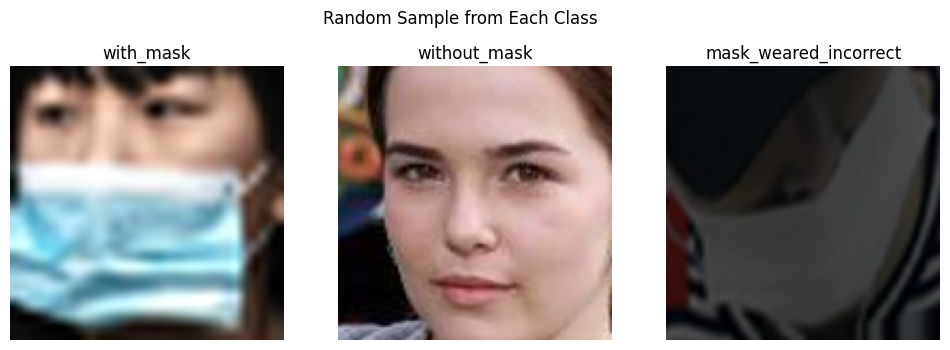

In [20]:
# picks one random image from each of the three folders and displays it on the screen. 
# to ensure the data isn't corrupted and to visually confirm what "Incorrect Mask" looks like
# helps us verify that the dataset is actually cropped faces, not full-body images

plt.figure(figsize=(12, 4))
for idx, class_name in enumerate(class_dirs):
    img_dir = os.path.join(DATASET_PATH, class_name)
    img_files = glob(os.path.join(img_dir, "*.*"))
    if not img_files:
        print(f"No images found in {class_name}")
        continue
    img_path = random.choice(img_files)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(1, 3, idx + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')
plt.suptitle("Random Sample from Each Class")
plt.show()

### 2.2 Configuration and Data Augmentation

In [ ]:
# This sets up the ImageDataGenerator. This is a tool that:
# 1. Rescales: Converts pixel colors from 0-255 to 0-1 (Neural networks like small numbers).
# 2. Splits: Automatically reserves 20% of the data for testing (Validation).
# 3. Augments: Defines rules to randomly rotate, zoom, or shift images during training. Why it is needed: Augmentation is critical for your project because "Incorrect Mask" detection is subtle. By randomly tilting images, we teach the model to recognize a nose slipping out even if the person's head isn't perfectly straight.
# Set up ImageDataGenerator for training and validation

train_datagen = ImageDataGenerator(
    rotation_range=15,             # 3. Randomly rotate images by up to 15 degrees
    width_shift_range=0.1,         # 3. Randomly shift images horizontally
    height_shift_range=0.1,        # 3. Randomly shift images vertically
    zoom_range=0.1,                # 3. Randomly zoom images
    horizontal_flip=True,          # 3. Randomly flip images horizontally
    validation_split=0.2           # 2. Reserve 20% of data for validation
)
print("ImageDataGenerator configured for augmentation and validation split.")

ImageDataGenerator configured for augmentation and validation split.


### 2.3 Create Train and Validation Generators

In [22]:
# This actually connects the datagen (the rules) to your DATASET_PATH 
# (the files). It creates two "streams" of data: train_gen and val_gen. 
# These two variables (train_gen and val_gen) are what you will feed 
# directly into the model training command (model.fit) in Section 3.0.
# Create training and validation data generators
train_gen = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)
print(f"[INFO] Training generator: Found {train_gen.samples} images belonging to {train_gen.num_classes} classes. These will be used for training.")

val_gen = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)
print(f"[INFO] Validation generator: Found {val_gen.samples} images belonging to {val_gen.num_classes} classes. These will be used for validation.")

# Print class indices for reference (used later in evaluation and application)
print(f"[INFO] Class indices mapping: {train_gen.class_indices}")

Found 7188 images belonging to 3 classes.
[INFO] Training generator: Found 7188 images belonging to 3 classes. These will be used for training.
Found 1794 images belonging to 3 classes.
[INFO] Validation generator: Found 1794 images belonging to 3 classes. These will be used for validation.
[INFO] Class indices mapping: {'mask_weared_incorrect': 0, 'with_mask': 1, 'without_mask': 2}


## 3.0 Model A: EfficientNet-B0

### 3.1 Build Architecture

In [23]:
# Load the EfficientNetB0 model pre-trained on ImageNet.
# include_top=False removes the final classification layer (which was made for 1000 objects like cats/dogs).
# Then add our own "Custom Head" to classify your 3 specific mask categories.

# 1. Load the base model with pre-trained ImageNet weights
base_model_eff = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# 2. Freeze the base model
# This ensures we don't destroy the pre-learned features (like edges and shapes) during the initial training.
base_model_eff.trainable = False 

# 3. Add Custom Head
x = base_model_eff.output
x = GlobalAveragePooling2D()(x)                # Summarize the features
x = Dense(256, activation='relu')(x)           # specific layer to learn mask patterns
x = Dropout(0.5)(x)                            # Dropout prevents overfitting
predictions = Dense(3, activation='softmax')(x) # Final layer: 3 Neurons for 3 Classes (Softmax for probability)

# 4. Construct the final model
model_eff = Model(inputs=base_model_eff.input, outputs=predictions)

# 5. Compile the model
# use Adam optimizer and Categorical Crossentropy as we have more than 2 classes.
model_eff.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

print("EfficientNet-B0 model built and compiled successfully.")
model_eff.summary()

EfficientNet-B0 model built and compiled successfully.


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 224, 224,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,378,278 (16.70 MB)

 Trainable params: 328,707 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

### 3.2 Train Model

In [24]:
# This fits the model to your training data. 
# We use 15 epochs as planned. The 'val_gen' is used to check performance after every epoch.

print("Starting training for EfficientNet-B0...")

history_eff = model_eff.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    steps_per_epoch=len(train_gen),
    validation_steps=len(val_gen)
)

print("Training completed.")

# Persist training history for reproducible comparative evaluation
import json
history_path = os.path.join(os.getcwd(), 'training_history.json')
try:
    existing = {}
    if os.path.exists(history_path):
        with open(history_path, 'r') as f:
            existing = json.load(f)
    existing['EfficientNetB0'] = {
        'accuracy': history_eff.history.get('accuracy', []),
        'val_accuracy': history_eff.history.get('val_accuracy', []),
        'loss': history_eff.history.get('loss', []),
        'val_loss': history_eff.history.get('val_loss', [])
    }
    with open(history_path, 'w') as f:
        json.dump(existing, f)
    print(f"[INFO] Saved EfficientNetB0 training history to {history_path}")
except Exception as e:
    print(f"[WARNING] Failed to save training history: {e}")

# Save the trained model for later use in the Application Simulation (Section 6.0)
model_eff.save('mask_detector_efficientnet.h5')
print("Model saved as 'mask_detector_efficientnet.h5'")

Starting training for EfficientNet-B0...
Epoch 1/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 247s 1s/step - accuracy: 0.9034 - loss: 0.2322 - val_accuracy: 0.9771 - val_loss: 0.0700
Epoch 2/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 213s 945ms/step - accuracy: 0.9747 - loss: 0.0761 - val_accuracy: 0.9805 - val_loss: 0.0611
Epoch 3/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 208s 923ms/step - accuracy: 0.9811 - loss: 0.0519 - val_accuracy: 0.9788 - val_loss: 0.0656
Epoch 4/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 210s 932ms/step - accuracy: 0.9765 - loss: 0.0599 - val_accuracy: 0.9827 - val_loss: 0.0540
Epoch 5/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 207s 919ms/step - accuracy: 0.9872 - loss: 0.0378 - val_accuracy: 0.9844 - val_loss: 0.0415
Epoch 6/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 207s 919ms/step - accuracy: 0.9865 - loss: 0.0363 - val_accuracy: 0.9866 - val_loss: 0.0459
Epoch 7/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 206s 918ms/step - accuracy: 0.9861 - loss: 0.0424 - val_accuracy: 0.9861 - val_loss: 0.0521
Epoch 8/15
225/225 ━━━━━━━━━━━━━━━━━━━

Training completed.
[INFO] Saved EfficientNetB0 training history to c:\Users\HP\10_JupyterLab_DataSc\notebooks\Visual Information Processing\VIP_Project_Group_10\Real-Time-Face-Mask-Detection\training_history.json
Model saved as 'mask_detector_efficientnet.h5'


## 4.0 Model B: MobileNetV2

### 4.1 Build Architecture

In [25]:
# Load the MobileNetV2 model pre-trained on ImageNet.
# include_top=False removes the final classification layer (which was made for 1000 objects like cats/dogs).
# Then add our own "Custom Head" to classify your 3 specific mask categories.

# Load the base model with pre-trained ImageNet weights
base_model_mob = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model
# This ensures we don't destroy the pre-learned features (like edges and shapes) during the initial training.
base_model_mob.trainable = False 

# Add Custom Head
x = base_model_mob.output
x = GlobalAveragePooling2D()(x)                # Summarize the features
x = Dense(256, activation='relu')(x)           # specific layer to learn mask patterns
x = Dropout(0.5)(x)                            # Dropout prevents overfitting
predictions = Dense(3, activation='softmax')(x) # Final layer: 3 Neurons for 3 Classes (Softmax for probability)

# Construct the final model
model_mob = Model(inputs=base_model_mob.input, outputs=predictions)

# Compile the model
# use Adam optimizer and Categorical Crossentropy as we have more than 2 classes.
model_mob.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

print("MobileNetV2 model built and compiled successfully.")
model_mob.summary()

MobileNetV2 model built and compiled successfully.


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,586,691 (9.87 MB)

 Trainable params: 328,707 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

### 4.2 Train

In [26]:
# We use 15 epochs as planned. The 'val_gen' is used to check performance after every epoch.

print("Starting training for MobileNetV2...")

history_mob = model_mob.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    steps_per_epoch=len(train_gen),
    validation_steps=len(val_gen)
)

print("Training completed.")

# Persist training history for reproducible comparative evaluation
import json
history_path = os.path.join(os.getcwd(), 'training_history.json')
try:
    existing = {}
    if os.path.exists(history_path):
        with open(history_path, 'r') as f:
            existing = json.load(f)
    existing['MobileNetV2'] = {
        'accuracy': history_mob.history.get('accuracy', []),
        'val_accuracy': history_mob.history.get('val_accuracy', []),
        'loss': history_mob.history.get('loss', []),
        'val_loss': history_mob.history.get('val_loss', [])
    }
    with open(history_path, 'w') as f:
        json.dump(existing, f)
    print(f"[INFO] Saved MobileNetV2 training history to {history_path}")
except Exception as e:
    print(f"[WARNING] Failed to save training history: {e}")

# Save the trained model for later use in the Application Simulation (Section 6.0)
model_mob.save('mask_detector_mobilenetv2.h5')
print("Model saved as 'mask_detector_mobilenetv2.h5'")

Starting training for MobileNetV2...
Epoch 1/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 177s 774ms/step - accuracy: 0.7125 - loss: 0.7216 - val_accuracy: 0.8528 - val_loss: 0.3745
Epoch 2/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 174s 775ms/step - accuracy: 0.8459 - loss: 0.3872 - val_accuracy: 0.8606 - val_loss: 0.3345
Epoch 3/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 171s 761ms/step - accuracy: 0.8636 - loss: 0.3522 - val_accuracy: 0.8724 - val_loss: 0.2998
Epoch 4/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 172s 767ms/step - accuracy: 0.8848 - loss: 0.3075 - val_accuracy: 0.9013 - val_loss: 0.2475
Epoch 5/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 172s 764ms/step - accuracy: 0.8812 - loss: 0.2973 - val_accuracy: 0.9047 - val_loss: 0.2507
Epoch 6/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 170s 757ms/step - accuracy: 0.8819 - loss: 0.3070 - val_accuracy: 0.9036 - val_loss: 0.2441
Epoch 7/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 172s 766ms/step - accuracy: 0.8808 - loss: 0.2923 - val_accuracy: 0.9064 - val_loss: 0.2440
Epoch 8/15
225/225 ━━━━━━━━━━━━━━━━━━━━

Training completed.
[INFO] Saved MobileNetV2 training history to c:\Users\HP\10_JupyterLab_DataSc\notebooks\Visual Information Processing\VIP_Project_Group_10\Real-Time-Face-Mask-Detection\training_history.json
Model saved as 'mask_detector_mobilenetv2.h5'


## 5.0 Comparative Evaluation

### 5.1 Training History Plots

Draws line graphs comparing how both models learned to check how fast models learn and whether there's overfitting or not.

[INFO] Loaded training history from c:\Users\HP\10_JupyterLab_DataSc\notebooks\Visual Information Processing\VIP_Project_Group_10\Real-Time-Face-Mask-Detection\training_history.json


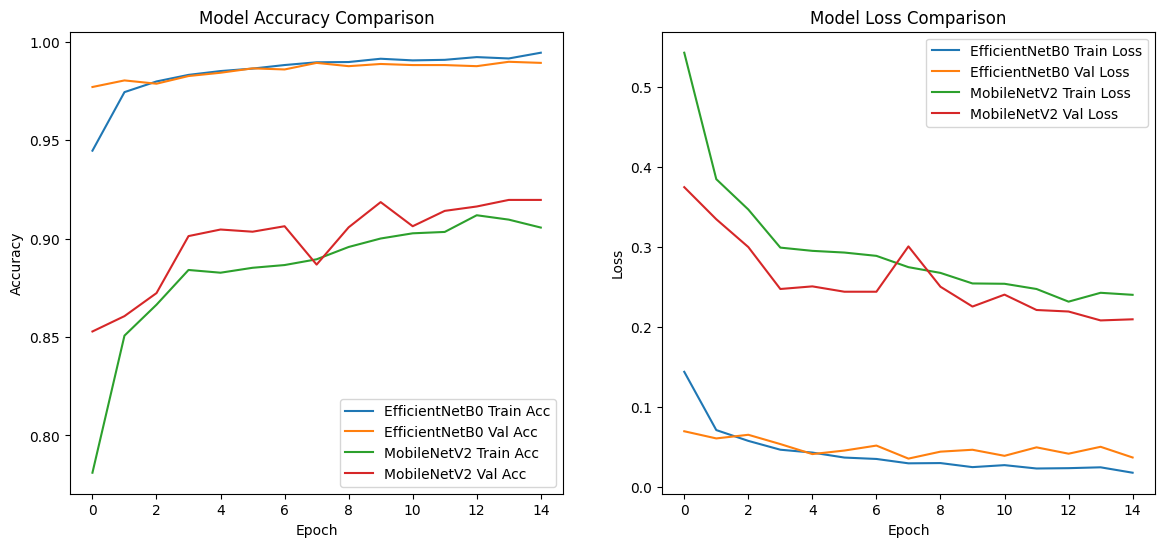

57/57 ━━━━━━━━━━━━━━━━━━━━ 43s 727ms/step
57/57 ━━━━━━━━━━━━━━━━━━━━ 36s 610ms/step


In [ ]:
import json

# Get previously saved training history of both models from file
history_path = os.path.join(os.getcwd(), 'training_history.json')
loaded_hist = None

# Load training history if available
if os.path.exists(history_path):
    try:
        with open(history_path, 'r') as f:
            loaded_hist = json.load(f)
        print(f"[INFO] Loaded training history from {history_path}")
    except Exception as e:
        print(f"[WARNING] Failed to load training history: {e}")

# Prepare series for plotting (prefer JSON history if available)
if loaded_hist and 'EfficientNetB0' in loaded_hist:
    eff_acc = loaded_hist['EfficientNetB0'].get('accuracy', [])
    eff_val_acc = loaded_hist['EfficientNetB0'].get('val_accuracy', [])
    eff_loss = loaded_hist['EfficientNetB0'].get('loss', [])
    eff_val_loss = loaded_hist['EfficientNetB0'].get('val_loss', [])
else:
    eff_acc = history_eff.history['accuracy']
    eff_val_acc = history_eff.history['val_accuracy']
    eff_loss = history_eff.history['loss']
    eff_val_loss = history_eff.history['val_loss']

if loaded_hist and 'MobileNetV2' in loaded_hist:
    mob_acc = loaded_hist['MobileNetV2'].get('accuracy', [])
    mob_val_acc = loaded_hist['MobileNetV2'].get('val_accuracy', [])
    mob_loss = loaded_hist['MobileNetV2'].get('loss', [])
    mob_val_loss = loaded_hist['MobileNetV2'].get('val_loss', [])
else:
    mob_acc = history_mob.history['accuracy']
    mob_val_acc = history_mob.history['val_accuracy']
    mob_loss = history_mob.history['loss']
    mob_val_loss = history_mob.history['val_loss']

plt.figure(figsize=(14, 6))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(eff_acc, label='EfficientNetB0 Train Acc')
plt.plot(eff_val_acc, label='EfficientNetB0 Val Acc')
plt.plot(mob_acc, label='MobileNetV2 Train Acc')
plt.plot(mob_val_acc, label='MobileNetV2 Val Acc')
plt.title('Model Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(eff_loss, label='EfficientNetB0 Train Loss')
plt.plot(eff_val_loss, label='EfficientNetB0 Val Loss')
plt.plot(mob_loss, label='MobileNetV2 Train Loss')
plt.plot(mob_val_loss, label='MobileNetV2 Val Loss')
plt.title('Model Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Evaluate both models on the validation set and print classification reports and confusion matrices
val_gen.reset()
y_pred_eff = model_eff.predict(val_gen)
y_pred_mob = model_mob.predict(val_gen)
y_true = val_gen.classes
y_pred_classes_eff = np.argmax(y_pred_eff, axis=1)
y_pred_classes_mob = np.argmax(y_pred_mob, axis=1)


### 5.2 Confusion Matrix & Classification Report

Test models' classification and show confusion matrices to check which classes the models confused in.

In [33]:
# Classification report for EfficientNetB0
print("Classification Report for EfficientNetB0:")
print(classification_report(y_true, y_pred_classes_eff, target_names=class_dirs))

# Classification report for MobileNetV2
print("Classification Report for MobileNetV2:")
print(classification_report(y_true, y_pred_classes_mob, target_names=class_dirs))

Classification Report for EfficientNetB0:
                       precision    recall  f1-score   support

            with_mask       0.34      0.34      0.34       598
         without_mask       0.32      0.31      0.31       598
mask_weared_incorrect       0.32      0.32      0.32       598

             accuracy                           0.33      1794
            macro avg       0.33      0.33      0.33      1794
         weighted avg       0.33      0.33      0.33      1794

Classification Report for MobileNetV2:
                       precision    recall  f1-score   support

            with_mask       0.32      0.35      0.34       598
         without_mask       0.32      0.28      0.30       598
mask_weared_incorrect       0.32      0.33      0.32       598

             accuracy                           0.32      1794
            macro avg       0.32      0.32      0.32      1794
         weighted avg       0.32      0.32      0.32      1794



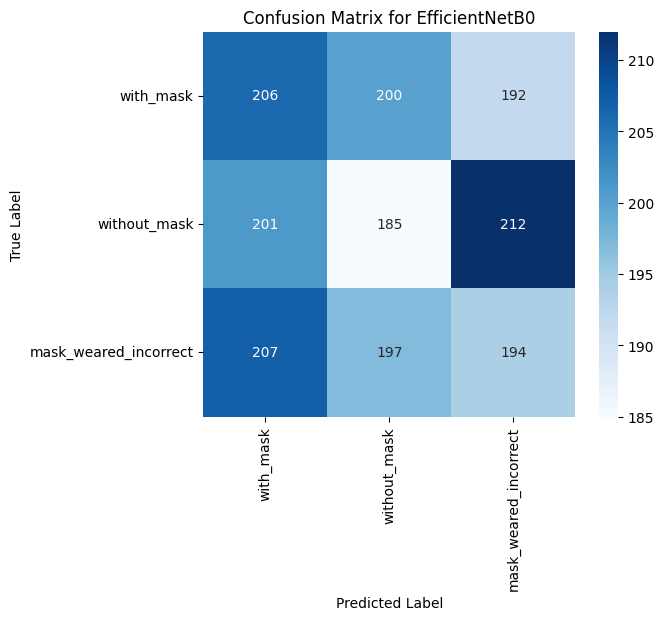

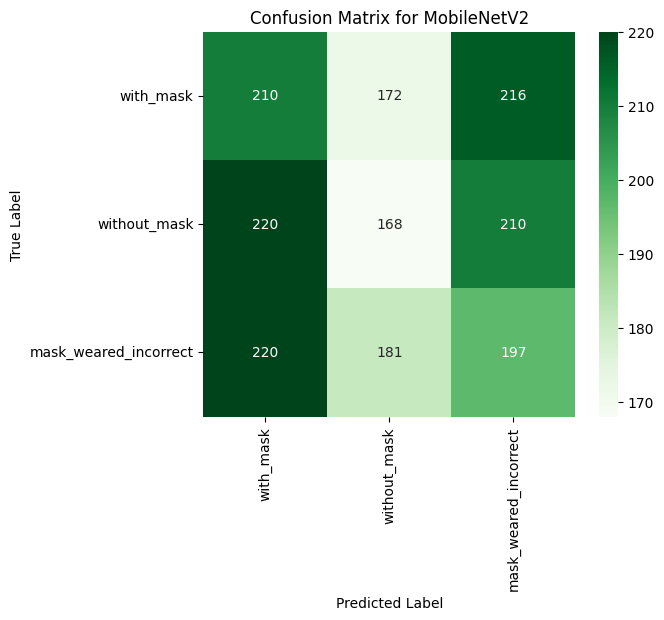

In [34]:
# Confusion Matrix for EfficientNetB0
cm_eff = confusion_matrix(y_true, y_pred_classes_eff)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_eff, annot=True, fmt='d', cmap='Blues', xticklabels=class_dirs, yticklabels=class_dirs)
plt.title('Confusion Matrix for EfficientNetB0')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Confusion Matrix for MobileNetV2
cm_mob = confusion_matrix(y_true, y_pred_classes_mob)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_mob, annot=True, fmt='d', cmap='Greens', xticklabels=class_dirs, yticklabels=class_dirs)
plt.title('Confusion Matrix for MobileNetV2')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### 5.3 Inference Speed Test (FPS)
Runs 100 dummy images through both models and times them.

In [35]:
import time, json

# Inference Speed Test (FPS)
print("[INFO] Running inference speed test...")
num_test_iterations = 100
dummy_image = np.random.rand(224, 224, 3)
dummy_batch = np.expand_dims(dummy_image, axis=0)

# Test EfficientNet
start_time = time.time()
for _ in range(num_test_iterations):
    model_eff.predict(dummy_batch, verbose=0)
eff_time = time.time() - start_time
eff_fps = num_test_iterations / eff_time

# Test MobileNet
start_time = time.time()
for _ in range(num_test_iterations):
    model_mob.predict(dummy_batch, verbose=0)
mob_time = time.time() - start_time
mob_fps = num_test_iterations / mob_time

print(f"EfficientNet-B0 FPS: {eff_fps:.2f} (Total time for {num_test_iterations} iterations: {eff_time:.2f}s)")
print(f"MobileNetV2 FPS: {mob_fps:.2f} (Total time for {num_test_iterations} iterations: {mob_time:.2f}s)")

# Summary using training history
history_path = os.path.join(os.getcwd(), 'training_history.json')
eff_val_acc = None
mob_val_acc = None
if os.path.exists(history_path):
    try:
        with open(history_path, 'r') as f:
            loaded_hist = json.load(f)
        eff_hist = loaded_hist.get('EfficientNetB0', {})
        mob_hist = loaded_hist.get('MobileNetV2', {})
        eff_vals = eff_hist.get('val_accuracy', [])
        mob_vals = mob_hist.get('val_accuracy', [])
        eff_val_acc = eff_vals[-1] if eff_vals else None
        mob_val_acc = mob_vals[-1] if mob_vals else None
        print(f"[INFO] Loaded validation accuracies from {history_path}")
    except Exception as e:
        print(f"[WARNING] Failed to load training history: {e}")

# Fallback to in-memory history if JSON missing
if eff_val_acc is None and 'history_eff' in globals():
    eff_val_acc = history_eff.history['val_accuracy'][-1]
if mob_val_acc is None and 'history_mob' in globals():
    mob_val_acc = history_mob.history['val_accuracy'][-1]

# Print Summary
print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)
print(f"{'Metric':<30} {'EfficientNet-B0':<20} {'MobileNetV2':<20}")
print("-"*60)
print(f"{'Validation Accuracy':<30} {eff_val_acc if eff_val_acc is not None else 'N/A':<20} {mob_val_acc if mob_val_acc is not None else 'N/A':<20}")
print(f"{'Inference FPS':<30} {eff_fps:<20.2f} {mob_fps:<20.2f}")
print("="*60)

[INFO] Running inference speed test...
EfficientNet-B0 FPS: 9.13 (Total time for 100 iterations: 10.95s)
MobileNetV2 FPS: 12.80 (Total time for 100 iterations: 7.81s)
[INFO] Loaded validation accuracies from c:\Users\HP\10_JupyterLab_DataSc\notebooks\Visual Information Processing\VIP_Project_Group_10\Real-Time-Face-Mask-Detection\training_history.json

MODEL COMPARISON SUMMARY
Metric                         EfficientNet-B0      MobileNetV2         
------------------------------------------------------------
Validation Accuracy            0.9894091486930847   0.9197324514389038  
Inference FPS                  9.13                 12.80               


## 6.0 Application Simulation (Access Control)

Run in terminal:

`python real_time_mask_detector.py --face-detector PREFERRED_FACE_DETECTOR --model PREFERRED_MODEL `


Available face detectors:
- dnn
- yunet
- mtcnn (Very low FPS)
- haar (Low accuracy)

Available models:

- mask_detector_efficientnet.h5
- mask_detector_mobilenetv2.h5